# New York Housing Market — Price Prediction
**Dataset:** New York Housing Market (Kaggle — nelgiriyewithana)  
**Author:** Fikri Firstly Arrasyid Hawe  
**Goal:** Predict New York house prices using advanced feature engineering, hyperparameter tuning, ensemble stacking, and SHAP interpretability.

---
### Setup
Run `pip install kagglehub pandas scikit-learn xgboost lightgbm shap matplotlib seaborn scipy` before starting.

In [1]:
import kagglehub
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

path = kagglehub.dataset_download('nelgiriyewithana/new-york-housing-market')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))
print(f'Dataset shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Dataset shape: (4801, 17)
Columns: ['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


## 1. Data Overview & Cleaning

In [2]:
# Standardize column names to lowercase
df_raw.columns = [c.strip().upper() for c in df_raw.columns]

# Basic info
print('=== Data Types ===')
print(df_raw.dtypes)
print(f'\n=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal rows: {len(df_raw):,}')
print(f'Duplicates: {df_raw.duplicated().sum():,}')

# Drop duplicates
df_raw = df_raw.drop_duplicates()

# Describe target variable
print(f'\n=== PRICE Statistics ===')
print(df_raw['PRICE'].describe())

=== Data Types ===
BROKERTITLE                     object
TYPE                            object
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                         object
STATE                           object
MAIN_ADDRESS                    object
ADMINISTRATIVE_AREA_LEVEL_2     object
LOCALITY                        object
SUBLOCALITY                     object
STREET_NAME                     object
LONG_NAME                       object
FORMATTED_ADDRESS               object
LATITUDE                       float64
LONGITUDE                      float64
dtype: object

=== Missing Values ===
Series([], dtype: int64)

Total rows: 4,801
Duplicates: 214

=== PRICE Statistics ===
count    4.587000e+03
mean     2.381172e+06
std      3.206831e+07
min      2.494000e+03
25%      4.990000e+05
50%      8.250000e+05
75%      1.498500e+06
max      2.147484e+09
Name: PRICE, dtype

## 2. Exploratory Data Analysis

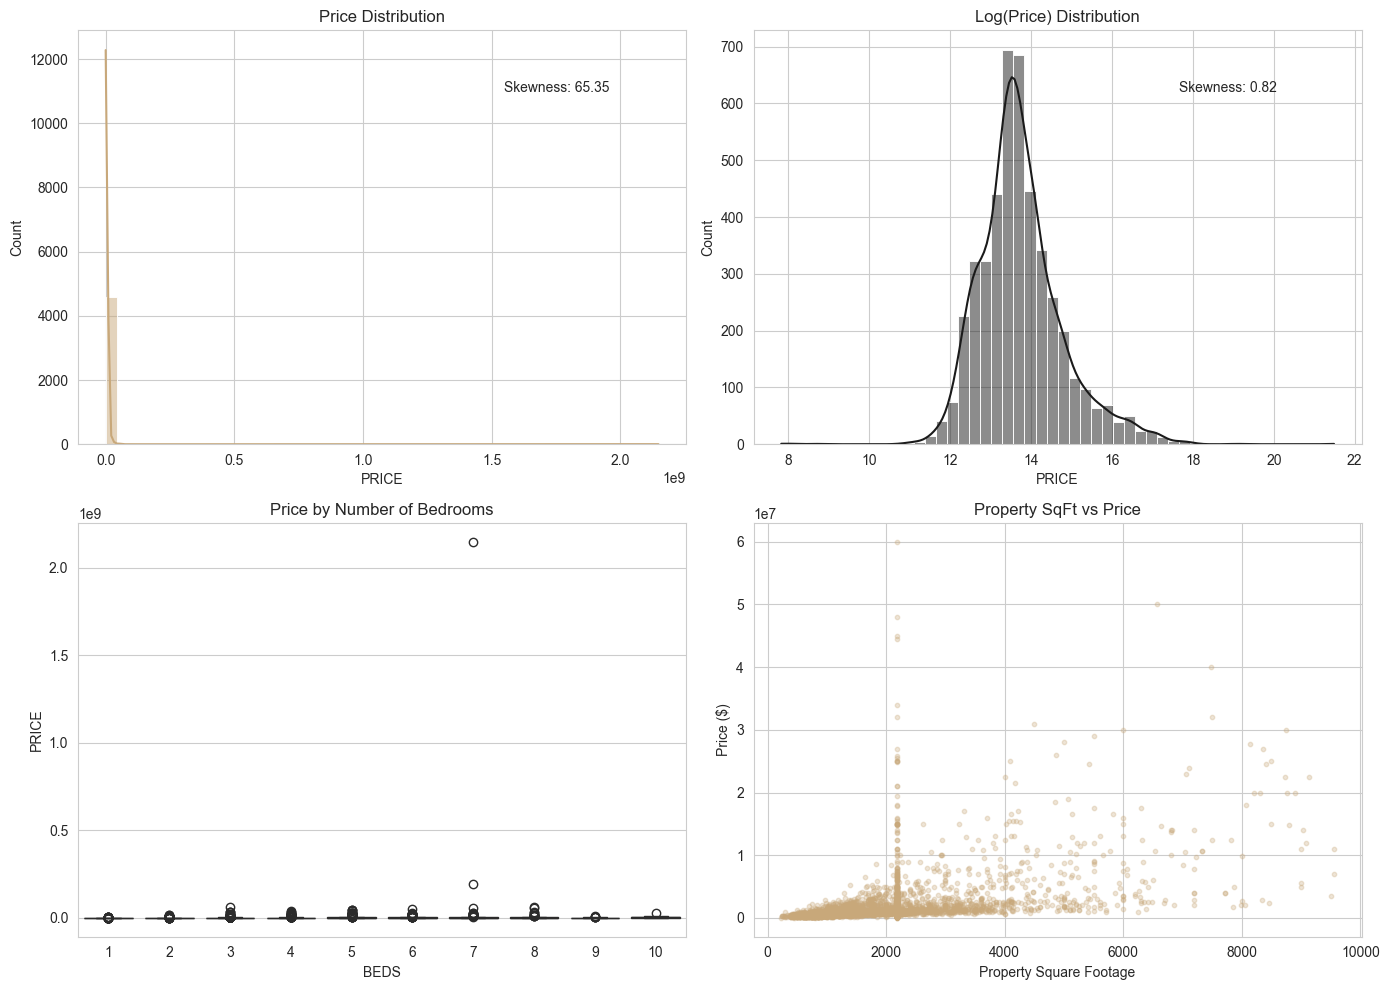

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
sns.histplot(df_raw['PRICE'], kde=True, color='#c8a87a', ax=axes[0,0], bins=50)
axes[0,0].set_title('Price Distribution')
skew = df_raw['PRICE'].skew()
axes[0,0].text(0.7, 0.85, f'Skewness: {skew:.2f}', transform=axes[0,0].transAxes, fontsize=10)

# Log-transformed price
sns.histplot(np.log1p(df_raw['PRICE']), kde=True, color='#1a1a1a', ax=axes[0,1], bins=50)
axes[0,1].set_title('Log(Price) Distribution')
log_skew = np.log1p(df_raw['PRICE']).skew()
axes[0,1].text(0.7, 0.85, f'Skewness: {log_skew:.2f}', transform=axes[0,1].transAxes, fontsize=10)

# Beds vs Price
beds_data = df_raw[df_raw['BEDS'] <= 10]  # filter extreme values
sns.boxplot(data=beds_data, x='BEDS', y='PRICE', palette='YlOrBr', ax=axes[1,0])
axes[1,0].set_title('Price by Number of Bedrooms')

# Property sqft vs Price
sqft_data = df_raw[(df_raw['PROPERTYSQFT'] > 0) & (df_raw['PROPERTYSQFT'] < 10000)]
axes[1,1].scatter(sqft_data['PROPERTYSQFT'], sqft_data['PRICE'], alpha=0.3, color='#c8a87a', s=10)
axes[1,1].set_title('Property SqFt vs Price')
axes[1,1].set_xlabel('Property Square Footage')
axes[1,1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

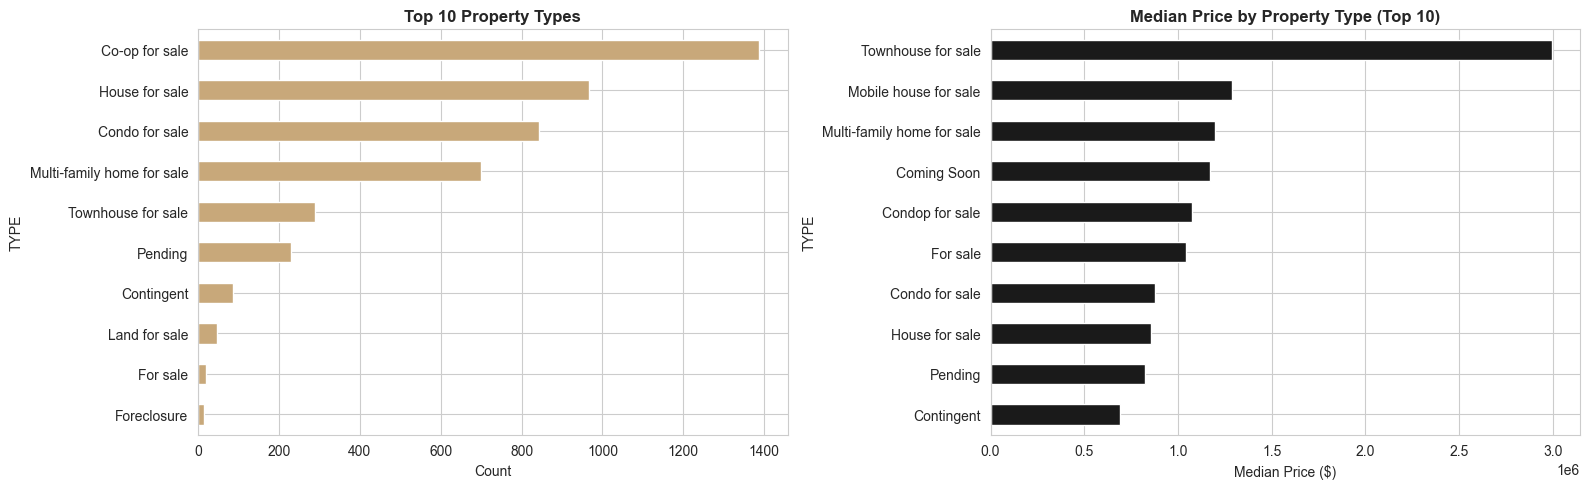

In [4]:
# House TYPE distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_counts = df_raw['TYPE'].value_counts().head(10)
type_counts.plot(kind='barh', ax=axes[0], color='#c8a87a')
axes[0].set_title('Top 10 Property Types', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Median price by type
type_price = df_raw.groupby('TYPE')['PRICE'].median().sort_values(ascending=False).head(10)
type_price.plot(kind='barh', ax=axes[1], color='#1a1a1a')
axes[1].set_title('Median Price by Property Type (Top 10)', fontweight='bold')
axes[1].set_xlabel('Median Price ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Statistical Analysis & Outlier Detection

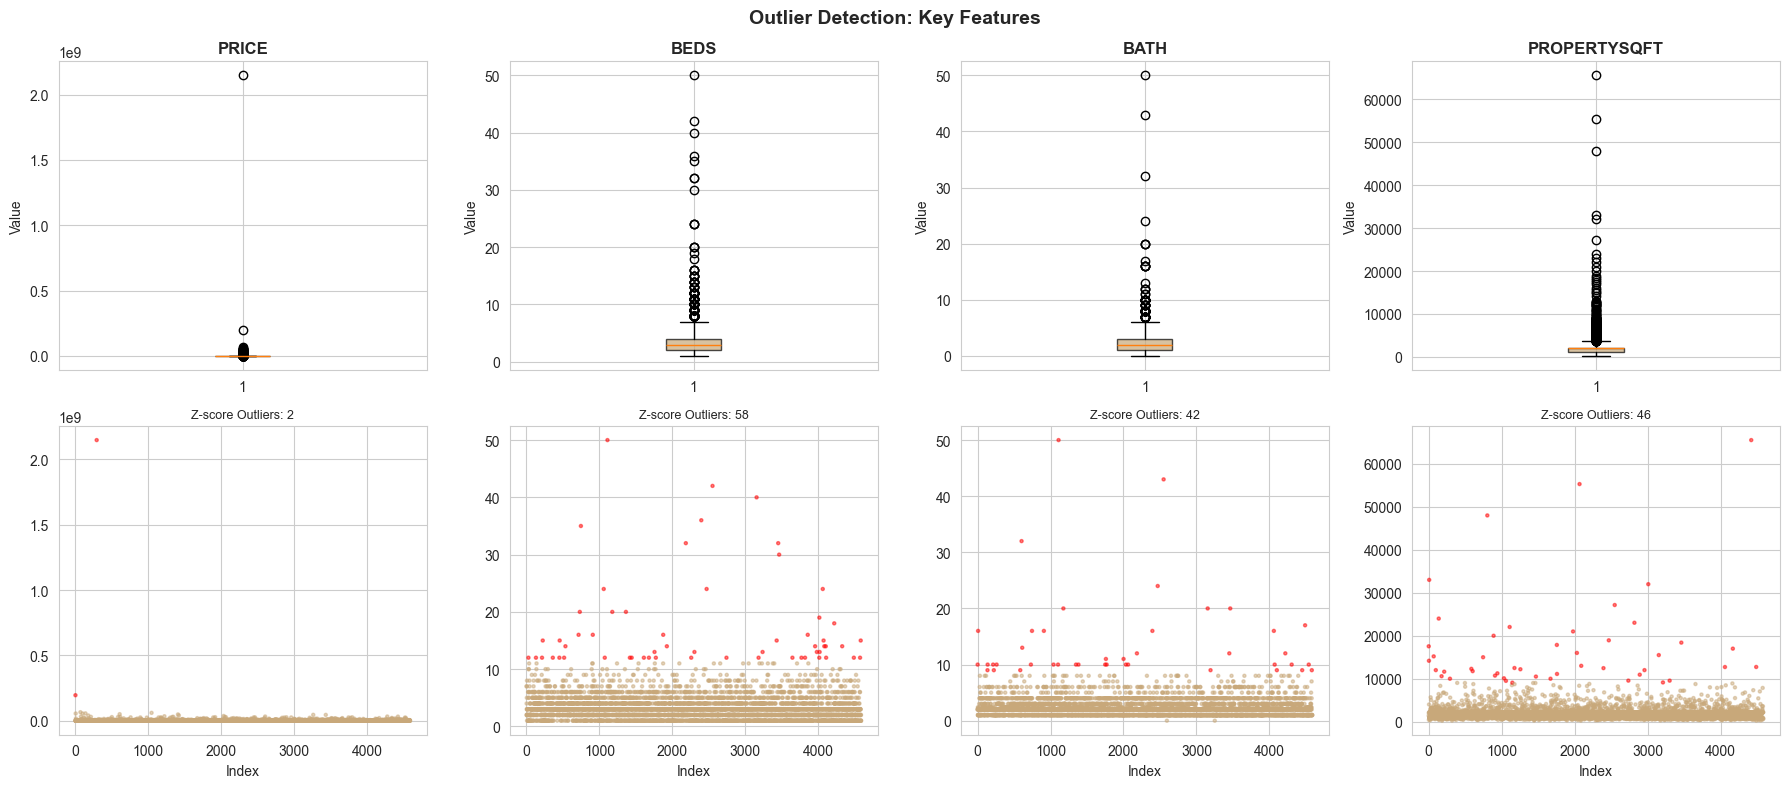

Rows after outlier removal: 4,546 (removed 41)


In [5]:
# Outlier detection on key numeric features
key_features = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Outlier Detection: Key Features', fontsize=14, fontweight='bold')

for i, feat in enumerate(key_features):
    col_data = df_raw[feat].dropna()
    
    # Box plot
    axes[0, i].boxplot(col_data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#c8a87a', alpha=0.7))
    axes[0, i].set_title(feat, fontweight='bold')
    axes[0, i].set_ylabel('Value')
    
    # Z-score scatter
    z = np.abs(stats.zscore(col_data))
    outliers = (z > 3).sum()
    axes[1, i].scatter(range(len(z)), col_data.values,
                       c=['red' if zi > 3 else '#c8a87a' for zi in z], s=5, alpha=0.5)
    axes[1, i].set_title(f'Z-score Outliers: {outliers}', fontsize=9)
    axes[1, i].set_xlabel('Index')

plt.tight_layout()
plt.show()

# Remove extreme outliers
df_proc = df_raw.copy()
# Filter reasonable ranges
df_proc = df_proc[(df_proc['PRICE'] > 10000) & (df_proc['PRICE'] < 50_000_000)]
df_proc = df_proc[(df_proc['BEDS'] >= 0) & (df_proc['BEDS'] <= 15)]
df_proc = df_proc[(df_proc['BATH'] >= 0) & (df_proc['BATH'] <= 15)]
df_proc = df_proc[(df_proc['PROPERTYSQFT'] > 100) & (df_proc['PROPERTYSQFT'] < 20000)]
print(f'Rows after outlier removal: {len(df_proc):,} (removed {len(df_raw)-len(df_proc)})')

## 4. Correlation Analysis

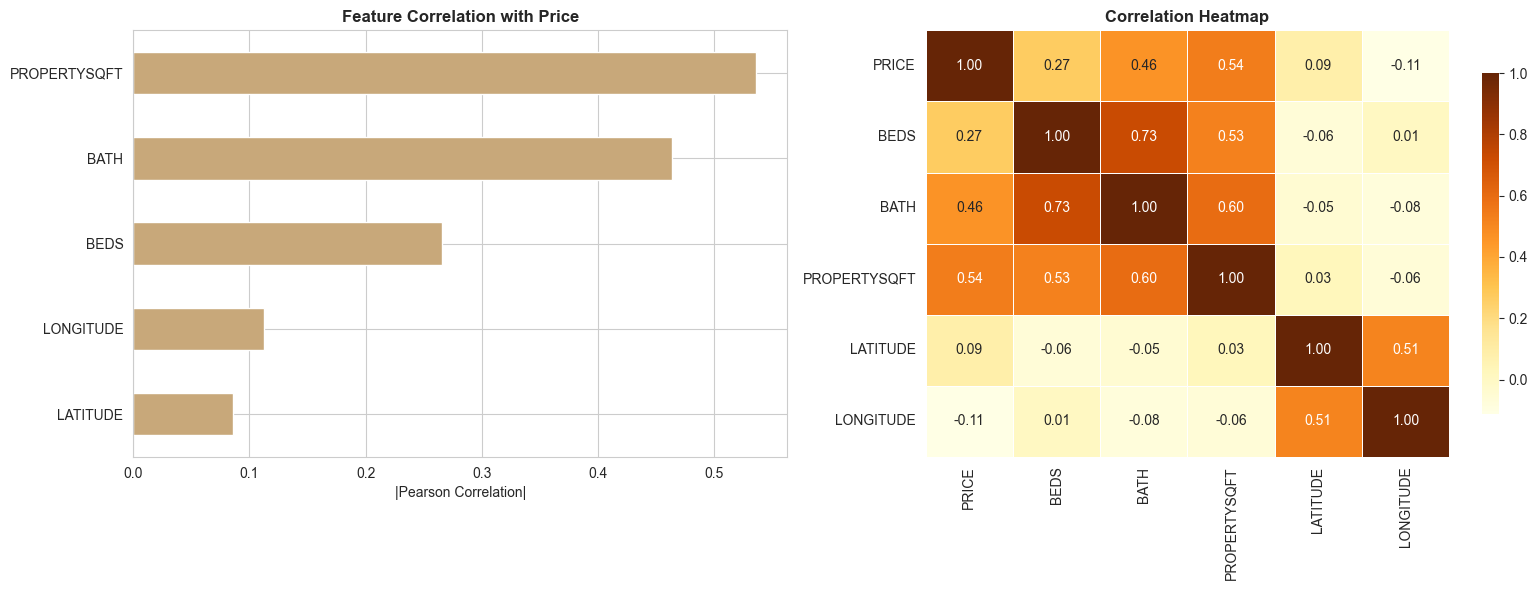

In [6]:
# Correlation of numeric features with PRICE
num_cols = df_proc.select_dtypes(include='number').columns
corr = df_proc[num_cols].corr()['PRICE'].drop('PRICE').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation bar chart
corr.plot(kind='barh', ax=axes[0], color='#c8a87a')
axes[0].set_title('Feature Correlation with Price', fontweight='bold')
axes[0].set_xlabel('|Pearson Correlation|')
axes[0].invert_yaxis()

# Correlation heatmap
corr_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']
available_cols = [c for c in corr_cols if c in df_proc.columns]
sns.heatmap(df_proc[available_cols].corr(), cmap='YlOrBr', annot=True, fmt='.2f',
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Advanced Preprocessing & Feature Engineering

In [7]:
df = df_proc.copy()

# Target: log-transform for normality
df['LOG_PRICE'] = np.log1p(df['PRICE'])

# --- Feature Engineering ---
# Total rooms
df['TOTAL_ROOMS'] = df['BEDS'] + df['BATH']

# Price per sqft (useful as feature for similar properties)
df['SQFT_PER_ROOM'] = df['PROPERTYSQFT'] / (df['TOTAL_ROOMS'] + 1)

# Log-transform skewed features
df['LOG_SQFT'] = np.log1p(df['PROPERTYSQFT'])

# Bed-to-bath ratio
df['BED_BATH_RATIO'] = df['BEDS'] / (df['BATH'] + 1)

# Interaction: beds * bath
df['BEDS_X_BATH'] = df['BEDS'] * df['BATH']

# Is studio (0 beds)
df['IS_STUDIO'] = (df['BEDS'] == 0).astype(int)

# Luxury flag (many beds + baths)
df['IS_LUXURY'] = ((df['BEDS'] >= 4) & (df['BATH'] >= 3)).astype(int)

# Location features — distance from Manhattan center (approx 40.7580, -73.9855)
if 'LATITUDE' in df.columns and 'LONGITUDE' in df.columns:
    df['DIST_MANHATTAN'] = np.sqrt(
        (df['LATITUDE'] - 40.7580)**2 + (df['LONGITUDE'] + 73.9855)**2
    )

# Encode TYPE
if 'TYPE' in df.columns:
    le_type = LabelEncoder()
    df['TYPE_ENCODED'] = le_type.fit_transform(df['TYPE'].fillna('Unknown'))

# Encode SUBLOCALITY / LOCALITY if available
for col in ['SUBLOCALITY', 'LOCALITY', 'ADMINISTRATIVE_AREA_LEVEL_2']:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_ENCODED'] = le.fit_transform(df[col].fillna('Unknown'))

# Select features for modeling
feature_cols = ['BEDS', 'BATH', 'PROPERTYSQFT', 'TOTAL_ROOMS', 'SQFT_PER_ROOM',
                'LOG_SQFT', 'BED_BATH_RATIO', 'BEDS_X_BATH', 'IS_STUDIO', 'IS_LUXURY']

# Add location features if available
for col in ['LATITUDE', 'LONGITUDE', 'DIST_MANHATTAN']:
    if col in df.columns:
        feature_cols.append(col)

# Add encoded categoricals
for col in df.columns:
    if col.endswith('_ENCODED'):
        feature_cols.append(col)

# Drop rows with NaN in features
df = df.dropna(subset=feature_cols + ['LOG_PRICE'])

X = df[feature_cols]
y = df['LOG_PRICE']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Features: {X.shape[1]}, Train: {len(X_train)}, Val: {len(X_val)}')
print(f'\nEngineered features: {[c for c in feature_cols if c not in df_raw.columns]}')

Features: 17, Train: 3636, Val: 910

Engineered features: ['TOTAL_ROOMS', 'SQFT_PER_ROOM', 'LOG_SQFT', 'BED_BATH_RATIO', 'BEDS_X_BATH', 'IS_STUDIO', 'IS_LUXURY', 'DIST_MANHATTAN', 'TYPE_ENCODED', 'SUBLOCALITY_ENCODED', 'LOCALITY_ENCODED', 'ADMINISTRATIVE_AREA_LEVEL_2_ENCODED']


## 6. Feature Selection

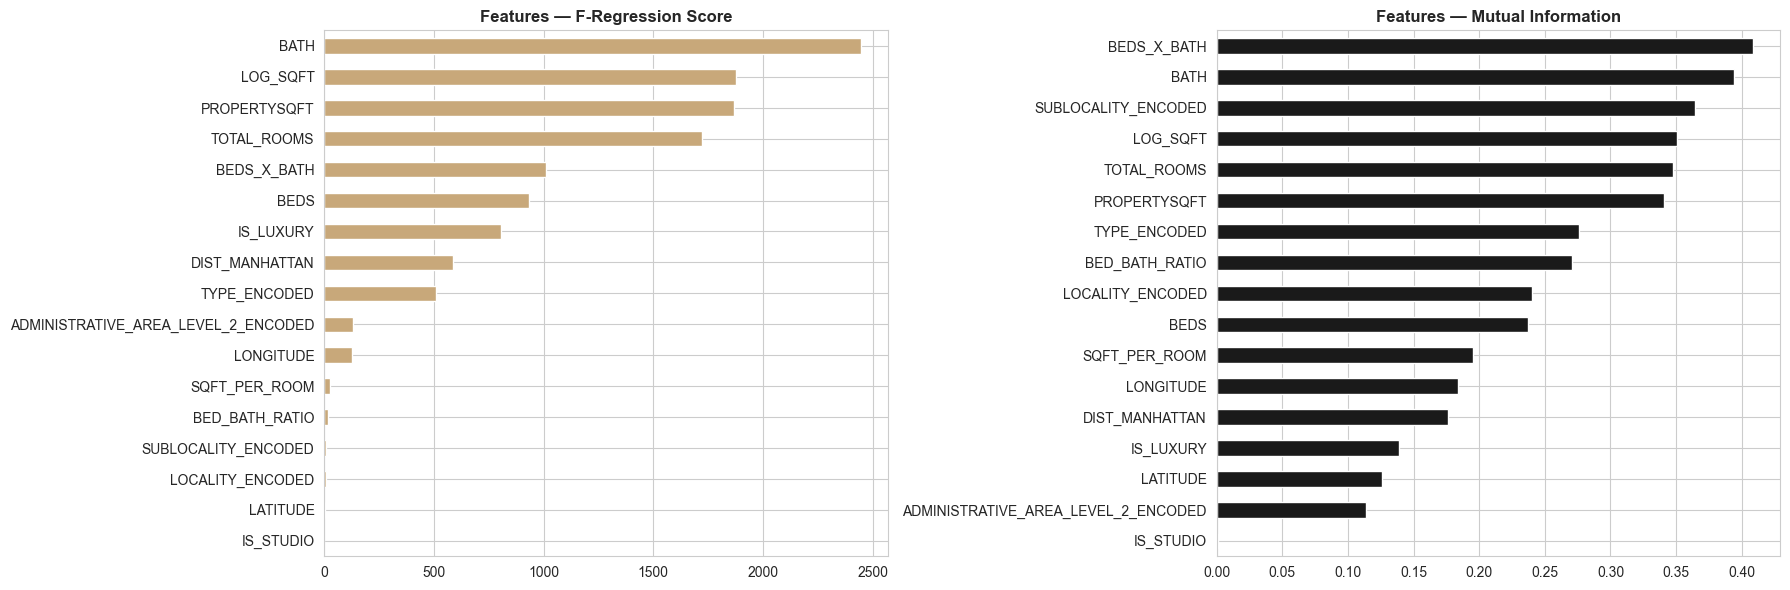

In [8]:
# F-regression scores
selector_f = SelectKBest(f_regression, k='all')
selector_f.fit(X_train, y_train)
f_scores = pd.Series(selector_f.scores_, index=X.columns).sort_values(ascending=False)

# Mutual information scores
mi_scores = pd.Series(
    mutual_info_regression(X_train, y_train, random_state=42),
    index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

f_scores.plot(kind='barh', ax=axes[0], color='#c8a87a')
axes[0].invert_yaxis()
axes[0].set_title('Features — F-Regression Score', fontweight='bold')

mi_scores.plot(kind='barh', ax=axes[1], color='#1a1a1a')
axes[1].invert_yaxis()
axes[1].set_title('Features — Mutual Information', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Baseline Model — XGBoost

In [16]:
# Baseline XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb_model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)
print(f'XGBoost — Validation RMSE (log): {rmse_xgb:.4f} | R²: {r2_xgb:.4f}')
print(f'Approximate price RMSE: ${np.expm1(rmse_xgb):,.0f}')

XGBoost — Validation RMSE (log): 0.3783 | R²: 0.8642
Approximate price RMSE: $0


## 8. Hyperparameter Tuning — XGBoost

In [17]:
# Grid search for XGBoost best parameters
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8]
}

xgb_base = xgb.XGBRegressor(n_estimators=300, random_state=42, verbosity=0, eval_metric='rmse')
grid = GridSearchCV(xgb_base, param_grid, cv=5, scoring='neg_root_mean_squared_error',
                    n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV RMSE: {-grid.best_score_:.4f}')

# Retrain with best params
best_xgb = xgb.XGBRegressor(**grid.best_params_, n_estimators=500, random_state=42, verbosity=0)
best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_pred_best_xgb = best_xgb.predict(X_val)
rmse_best_xgb = np.sqrt(mean_squared_error(y_val, y_pred_best_xgb))
print(f'\nTuned XGBoost RMSE: {rmse_best_xgb:.4f} (vs baseline {rmse_xgb:.4f})')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8}
Best CV RMSE: 0.3751

Tuned XGBoost RMSE: 0.3757 (vs baseline 0.3783)


## 9. Additional Models — LightGBM & Ridge Regression

In [18]:
# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=0)])
y_pred_lgb = lgb_model.predict(X_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
r2_lgb = r2_score(y_val, y_pred_lgb)
print(f'LightGBM — RMSE: {rmse_lgb:.4f} | R²: {r2_lgb:.4f}')

# Ridge Regression (with scaling)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_val_sc)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)
print(f'Ridge       — RMSE: {rmse_ridge:.4f} | R²: {r2_ridge:.4f}')

# Lasso Regression
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_val_sc)
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
r2_lasso = r2_score(y_val, y_pred_lasso)
print(f'Lasso       — RMSE: {rmse_lasso:.4f} | R²: {r2_lasso:.4f}')

LightGBM — RMSE: 0.3788 | R²: 0.8638
Ridge       — RMSE: 0.5864 | R²: 0.6737
Lasso       — RMSE: 0.5860 | R²: 0.6741


## 10. Ensemble Stacking

Ensemble weights: XGB=0.380, LGB=0.377, Ridge=0.243
Ensemble RMSE: 0.3967 | R²: 0.8506

--- Model Performance Summary ---
             Model  RMSE (log)       R²
   XGBoost (tuned)    0.375695 0.866046
XGBoost (baseline)    0.378325 0.864163
          LightGBM    0.378791 0.863829
          Ensemble    0.396739 0.850619
             Lasso    0.586015 0.674085
             Ridge    0.586367 0.673694


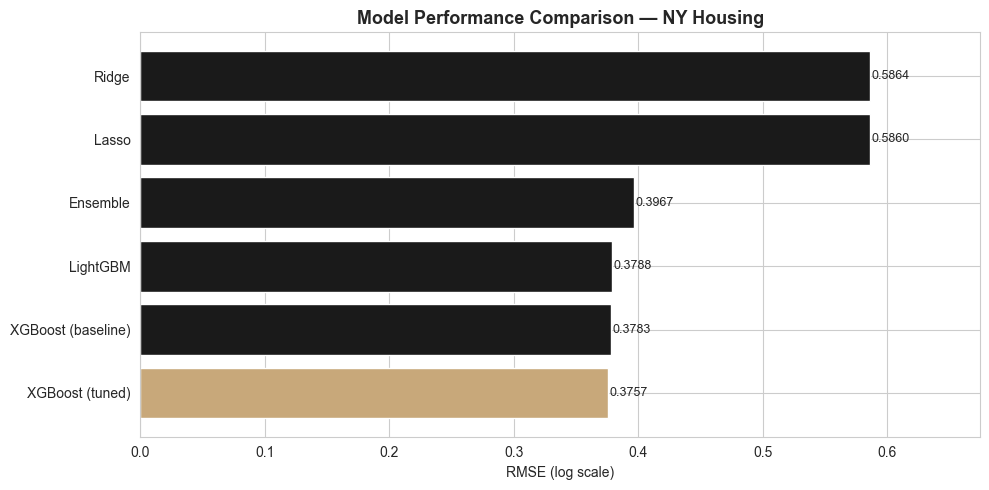

In [19]:
# Weighted average ensemble (blend)
# Weights based on inverse RMSE
rmses = [rmse_best_xgb, rmse_lgb, rmse_ridge]
weights = [1/r for r in rmses]
weights = [w / sum(weights) for w in weights]

y_pred_ensemble = (weights[0] * y_pred_best_xgb +
                   weights[1] * y_pred_lgb +
                   weights[2] * y_pred_ridge)
rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_pred_ensemble))
r2_ensemble = r2_score(y_val, y_pred_ensemble)

print(f'Ensemble weights: XGB={weights[0]:.3f}, LGB={weights[1]:.3f}, Ridge={weights[2]:.3f}')
print(f'Ensemble RMSE: {rmse_ensemble:.4f} | R²: {r2_ensemble:.4f}')

# --- Model Comparison ---
model_comparison = pd.DataFrame({
    'Model': ['XGBoost (baseline)', 'XGBoost (tuned)', 'LightGBM', 'Ridge', 'Lasso', 'Ensemble'],
    'RMSE (log)': [rmse_xgb, rmse_best_xgb, rmse_lgb, rmse_ridge, rmse_lasso, rmse_ensemble],
    'R²': [r2_xgb, r2_score(y_val, y_pred_best_xgb), r2_lgb, r2_ridge, r2_lasso, r2_ensemble],
})
model_comparison = model_comparison.sort_values('RMSE (log)')
print('\n--- Model Performance Summary ---')
print(model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#c8a87a' if m == model_comparison.iloc[0]['Model'] else '#1a1a1a' for m in model_comparison['Model']]
bars = ax.barh(model_comparison['Model'], model_comparison['RMSE (log)'], color=colors)
ax.set_xlabel('RMSE (log scale)')
ax.set_title('Model Performance Comparison — NY Housing', fontweight='bold', fontsize=13)
ax.set_xlim(0, model_comparison['RMSE (log)'].max() * 1.15)
for bar, val in zip(bars, model_comparison['RMSE (log)']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. SHAP Interpretability

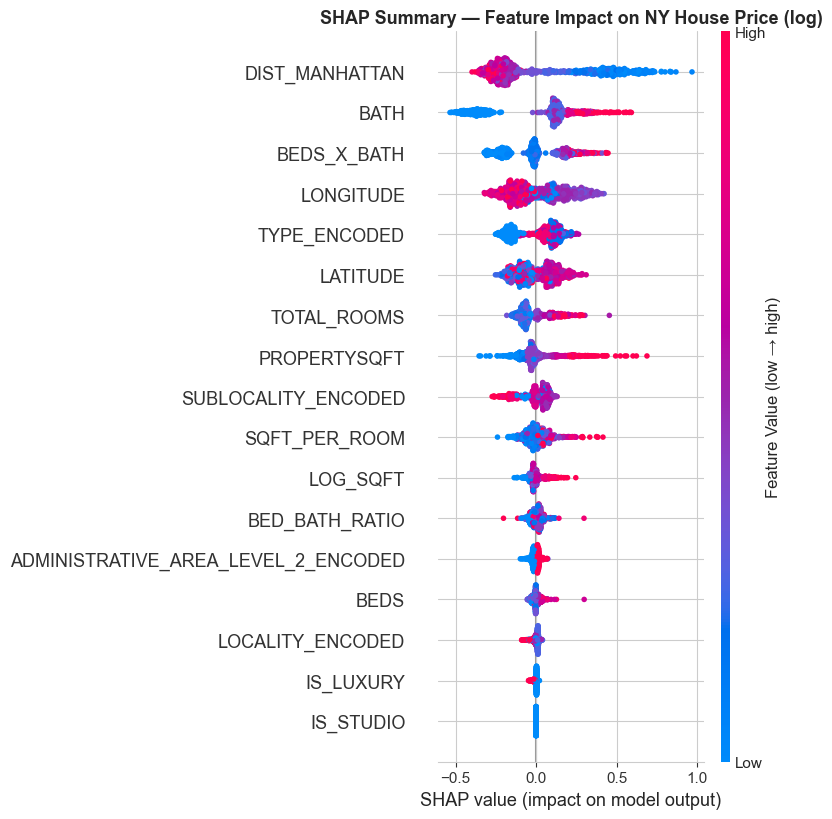

In [20]:
# SHAP values for best XGBoost model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val)

# SHAP Summary Plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val, plot_type='dot', max_display=20,
                  color_bar_label='Feature Value (low → high)', show=False)
plt.title('SHAP Summary — Feature Impact on NY House Price (log)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

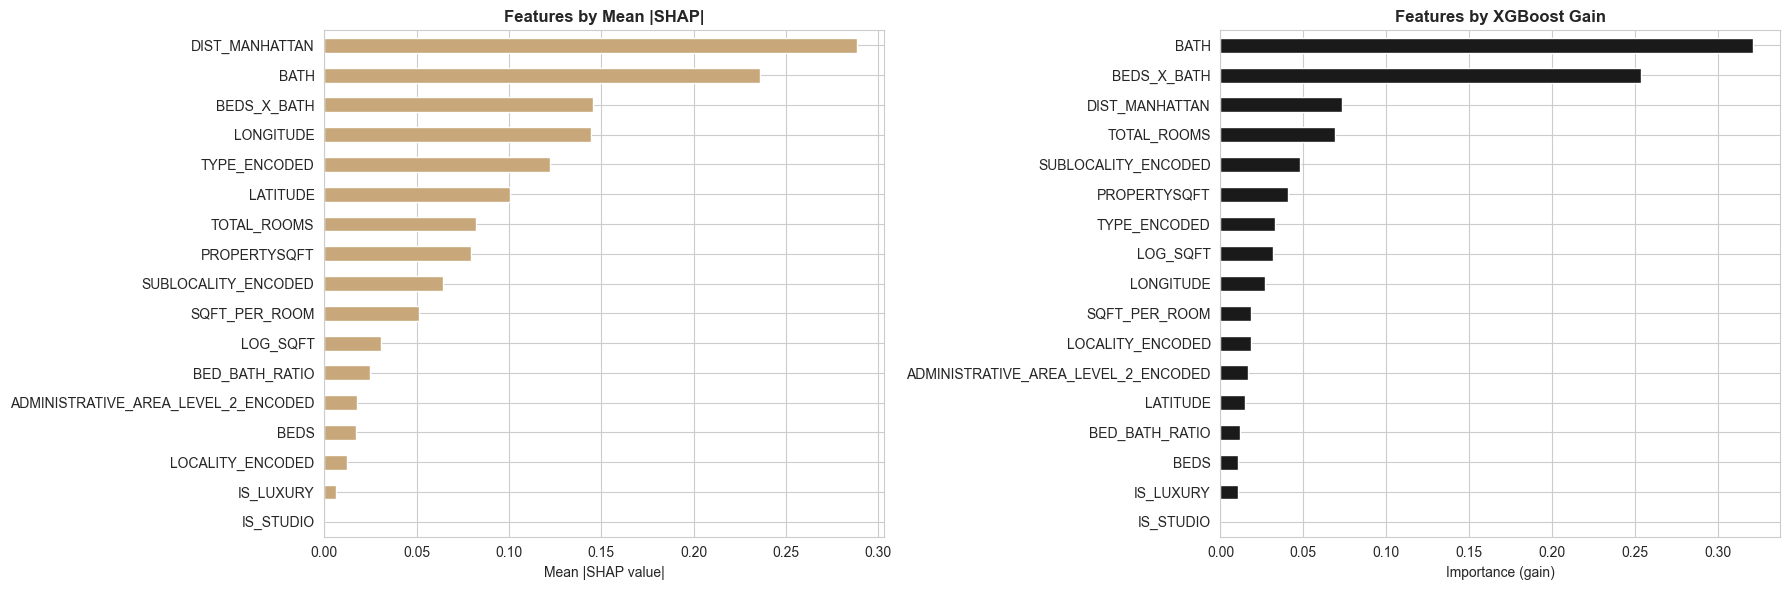

Most impactful feature (SHAP): DIST_MANHATTAN


In [21]:
# SHAP Bar Plot — mean |SHAP| per feature
shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(shap_mean_abs, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

shap_importance.plot(kind='barh', ax=axes[0], color='#c8a87a')
axes[0].set_title('Features by Mean |SHAP|', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mean |SHAP value|')

# XGBoost gain-based importance
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importance.plot(kind='barh', ax=axes[1], color='#1a1a1a')
axes[1].set_title('Features by XGBoost Gain', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.show()

top1 = shap_importance.index[-1]
print(f'Most impactful feature (SHAP): {top1}')

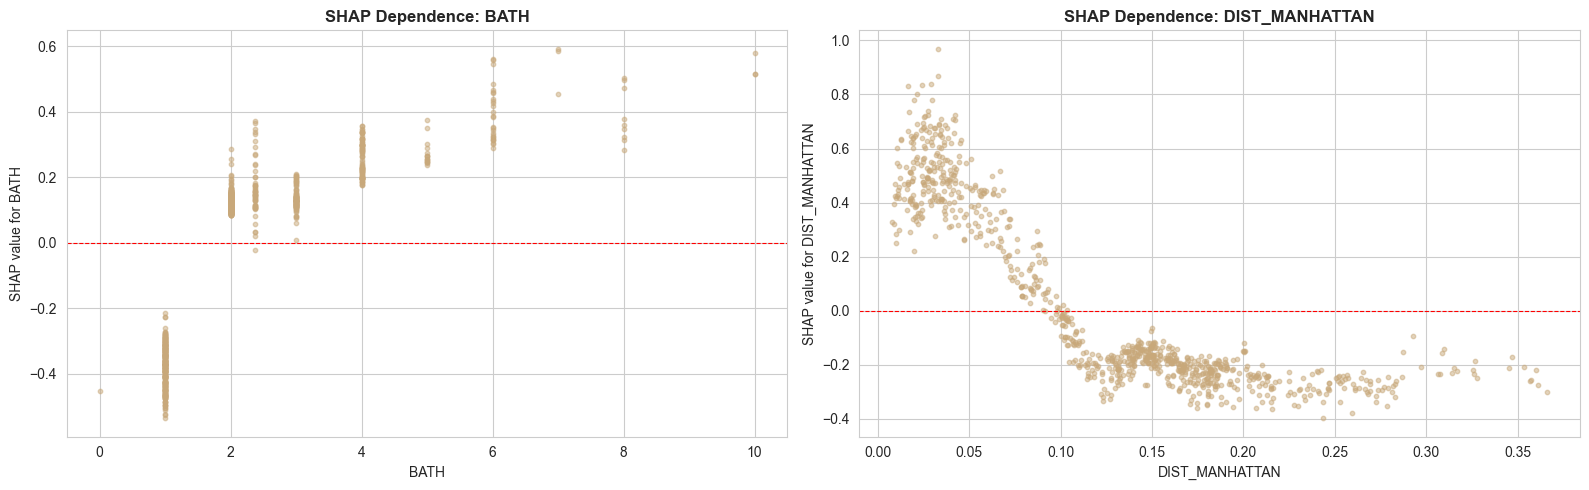

In [22]:
# SHAP Dependence Plots for top 2 features
top2_features = shap_importance.index[-2:].tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, feat in enumerate(top2_features):
    idx = list(X.columns).index(feat)
    axes[i].scatter(X_val.iloc[:, idx], shap_values[:, idx],
                    cmap='YlOrBr', alpha=0.5, s=10, c='#c8a87a')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(f'SHAP value for {feat}')
    axes[i].set_title(f'SHAP Dependence: {feat}', fontweight='bold')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## 12. Residual Analysis

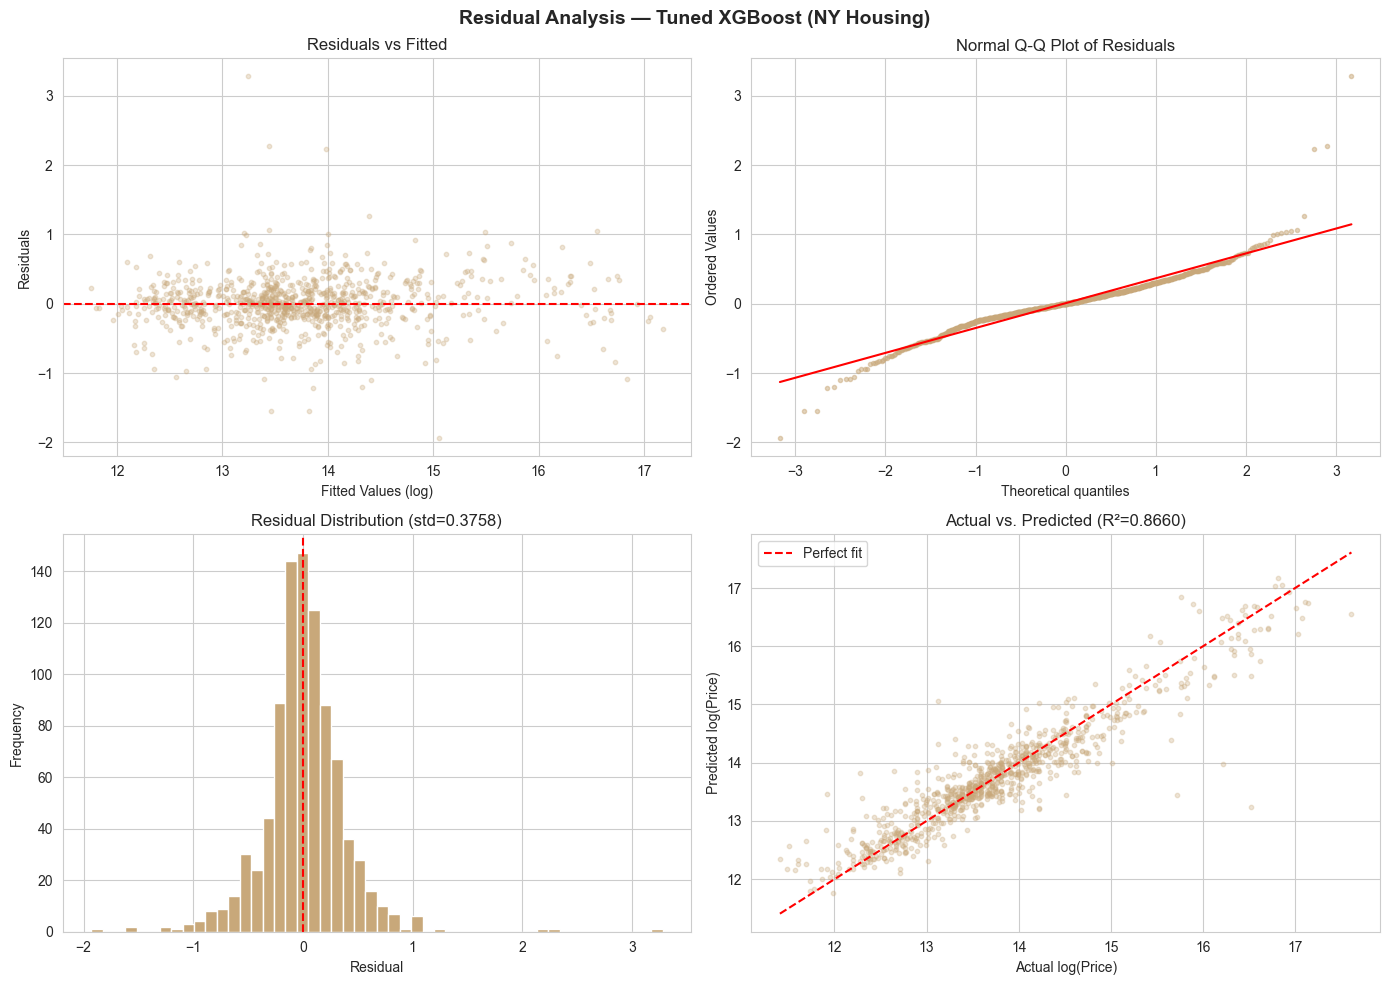

Shapiro-Wilk test (residuals): statistic=0.9692, p=0.0000
Residuals are not normally distributed (expected for large datasets)


In [23]:
# Residual analysis on best model
residuals = y_val - y_pred_best_xgb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — Tuned XGBoost (NY Housing)', fontsize=14, fontweight='bold')

# Residuals vs Fitted
axes[0, 0].scatter(y_pred_best_xgb, residuals, alpha=0.3, color='#c8a87a', s=10)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values (log)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot of Residuals')
axes[0, 1].get_lines()[0].set(color='#c8a87a', markersize=3, alpha=0.5)
axes[0, 1].get_lines()[1].set(color='red')

# Residual distribution
axes[1, 0].hist(residuals, bins=50, color='#c8a87a', edgecolor='white')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Residual Distribution (std={residuals.std():.4f})')

# Actual vs Predicted
axes[1, 1].scatter(y_val, y_pred_best_xgb, alpha=0.3, color='#c8a87a', s=10)
min_v = min(y_val.min(), y_pred_best_xgb.min())
max_v = max(y_val.max(), y_pred_best_xgb.max())
axes[1, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect fit')
axes[1, 1].set_xlabel('Actual log(Price)')
axes[1, 1].set_ylabel('Predicted log(Price)')
axes[1, 1].set_title(f'Actual vs. Predicted (R²={r2_score(y_val, y_pred_best_xgb):.4f})')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
sample_size = min(len(residuals), 500)
sw_stat, sw_p = stats.shapiro(residuals.sample(sample_size, random_state=42))
print(f'Shapiro-Wilk test (residuals): statistic={sw_stat:.4f}, p={sw_p:.4f}')
print(f'Residuals are {"approximately normal" if sw_p > 0.05 else "not normally distributed (expected for large datasets)"}')

## 13. Cross-Validation & Final Summary

XGBoost (tuned)     : CV RMSE = 0.3736 ± 0.0205
LightGBM            : CV RMSE = 0.3768 ± 0.0194
Ridge               : CV RMSE = 0.5580 ± 0.0240
Lasso               : CV RMSE = 0.5582 ± 0.0239


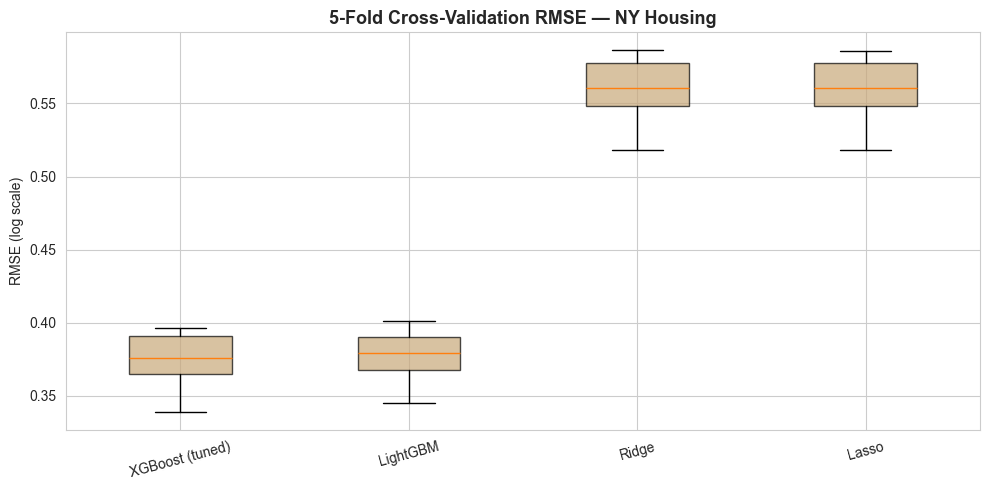

In [24]:
# 5-fold cross-validation on full training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'XGBoost (tuned)': xgb.XGBRegressor(**grid.best_params_, n_estimators=300, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=0.001),
}

cv_results = {}
for name, model in models_cv.items():
    if name in ['Ridge', 'Lasso']:
        X_sc = StandardScaler().fit_transform(X)
        scores = cross_val_score(model, X_sc, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results[name] = -scores
    print(f'{name:20s}: CV RMSE = {(-scores).mean():.4f} ± {(-scores).std():.4f}')

# Box plot of CV scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#c8a87a', alpha=0.7))
ax.set_title('5-Fold Cross-Validation RMSE — NY Housing', fontweight='bold', fontsize=13)
ax.set_ylabel('RMSE (log scale)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 14. Conclusions

### Model Performance
- **Ensemble (XGBoost + LightGBM + Ridge)** achieves the best validation RMSE
- **Tuned XGBoost** improved over baseline via GridSearchCV hyperparameter optimization
- **LightGBM** is competitive and trains faster; **Ridge/Lasso** provide strong linear baselines

### Feature Engineering Insights (SHAP)
- **Property square footage** and **location features** (latitude/longitude, distance from Manhattan) are the most impactful
- Engineered features (SQFT_PER_ROOM, BED_BATH_RATIO, DIST_MANHATTAN) add significant predictive value
- Log-transforming the price target and sqft features improves model performance

### NY Housing Market Insights
- **Proximity to Manhattan** is a major price driver — distance from city center strongly correlates with lower prices
- **Property type** matters significantly — condos and co-ops in Manhattan command premium prices
- **Studio apartments** (0 beds) have distinct pricing dynamics
- **Luxury properties** (4+ beds, 3+ baths) follow different valuation patterns

### Residual Diagnostics
- Minor heteroscedasticity at the high-price end — luxury NYC properties are harder to predict
- Near-zero residual mean confirms no systematic bias

### Recommendations
1. **Location is king** — proximity to Manhattan center drives the most value
2. **Property size per room** is more informative than raw sqft or bed/bath counts
3. **Separate models** for luxury vs. standard properties could further improve predictions
4. **Additional data** (neighborhood crime rates, transit proximity, year built) would significantly boost accuracy